# 03 — Adaptação binária → triagem em 3 níveis

**Projeto:** Medical Triage MLOps  
**Modelo-base:** `Yuvrajxms09/biobert-triage-classifier`

## Objetivo

O modelo pré-treinado produz duas probabilidades:

- `urgent`
- `non-urgent`

Para adaptar essa saída ao objetivo acadêmico do projeto, usamos uma **regra de decisão com zona de incerteza**:

```text
alta confiança em urgent      → urgente
baixa confiança / ambiguidade → atenção
alta confiança em non-urgent  → normal
```

A classe **atenção** não é uma classe aprendida diretamente pelo BioBERT. Ela representa uma **zona de incerteza operacional** em que o modelo não demonstra confiança suficiente para classificar o caso como claramente urgente ou claramente não urgente.

> Esta abordagem é uma heurística de pseudo-rotulagem para fins acadêmicos. Ela não corresponde a uma escala clínica validada.

## 1. Bibliotecas e configurações

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

CONFIDENCE_THRESHOLD = 0.70

COLORS = {
    "normal": "#16A085",
    "atenção": "#F4B942",
    "urgente": "#D63031",
}

## 2. Carregamento do piloto

Este notebook parte do arquivo:

```text
data/processed/triage_pilot_biobert.csv
```

Ele deve conter:

- `medical_abstract`
- `urgent_score`
- `nonurgent_score`
- `confidence`

In [2]:
def locate_project_root() -> Path:
    current = Path.cwd().resolve()

    for candidate in [current, current.parent, current.parent.parent]:
        expected = candidate / "data" / "processed" / "triage_pilot_biobert.csv"
        if expected.exists():
            return candidate

    raise FileNotFoundError(
        "Não encontrei data/processed/triage_pilot_biobert.csv. "
        "Execute primeiro o notebook 02_pilot_pseudolabel_biobert.ipynb."
    )


PROJECT_ROOT = locate_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

pilot_path = PROCESSED_DIR / "triage_pilot_biobert.csv"
pilot = pd.read_csv(pilot_path)

required_columns = {
    "medical_abstract",
    "urgent_score",
    "nonurgent_score",
    "confidence",
}

missing = required_columns - set(pilot.columns)

if missing:
    raise ValueError(f"Colunas ausentes no arquivo piloto: {sorted(missing)}")

print(f"Registros carregados: {len(pilot)}")
display(pilot.head())

Registros carregados: 60


,medical_abstract,n_tokens,sera_truncado,triage_prediction,urgent_score,nonurgent_score,confidence
0,The value of immunohistochemistry for collagen IV expression in colorectal carcinomas. The Dukes' classification has...,411,True,non-urgent,0.1950,0.8050,0.8050
1,In vitro drug sensitivity of cells from children with leukemia using the MTT assay with improved culture conditions....,499,True,non-urgent,0.3782,0.6218,0.6218
2,"Postarthroscopy analgesia with bupivacaine. A prospective, randomized, blinded evaluation. The analgesic effect of i...",225,False,non-urgent,0.1708,0.8292,0.8292
3,Indirect revascularization of the lower extremity by means of microvascular free-muscle flap--a preliminary report. ...,285,True,non-urgent,0.4769,0.5231,0.5231
4,Visceral protothecosis mimicking sclerosing cholangitis in an immunocompetent host: successful antifungal therapy. A...,269,True,urgent,0.6623,0.3377,0.6623


## 3. Regra de adaptação para três classes

Com `CONFIDENCE_THRESHOLD = 0.70`:

- **urgente**: `urgent_score >= 0.70`
- **normal**: `nonurgent_score >= 0.70`
- **atenção**: nenhum dos lados alcança 0.70

Como as probabilidades somam aproximadamente 1, a zona de atenção fica aproximadamente entre `0.30` e `0.70` no `urgent_score`.

In [3]:
def map_to_three_levels(
    urgent_score: float,
    nonurgent_score: float,
    threshold: float = CONFIDENCE_THRESHOLD,
) -> str:
    if urgent_score >= threshold:
        return "urgente"

    if nonurgent_score >= threshold:
        return "normal"

    return "atenção"


pilot["triage_level"] = pilot.apply(
    lambda row: map_to_three_levels(
        urgent_score=row["urgent_score"],
        nonurgent_score=row["nonurgent_score"],
    ),
    axis=1,
)

display(
    pilot[
        [
            "medical_abstract",
            "urgent_score",
            "nonurgent_score",
            "confidence",
            "triage_level",
        ]
    ].head(10)
)

,medical_abstract,urgent_score,nonurgent_score,confidence,triage_level
0,The value of immunohistochemistry for collagen IV expression in colorectal carcinomas. The Dukes' classification has...,0.1950,0.8050,0.8050,normal
1,In vitro drug sensitivity of cells from children with leukemia using the MTT assay with improved culture conditions....,0.3782,0.6218,0.6218,atenção
2,"Postarthroscopy analgesia with bupivacaine. A prospective, randomized, blinded evaluation. The analgesic effect of i...",0.1708,0.8292,0.8292,normal
3,Indirect revascularization of the lower extremity by means of microvascular free-muscle flap--a preliminary report. ...,0.4769,0.5231,0.5231,atenção
4,Visceral protothecosis mimicking sclerosing cholangitis in an immunocompetent host: successful antifungal therapy. A...,0.6623,0.3377,0.6623,atenção
5,Evolution of energy expenditure and nitrogen excretion in severe head-injured patients. OBJECTIVE: The aim of the st...,0.6358,0.3642,0.6358,atenção
6,Warning: fatal reaction to the use of fibrin glue in deep hepatic wounds. Case reports. Two cases of severe hypotens...,0.8448,0.1552,0.8448,urgente
7,Activation of erythropoietin receptors by Friend viral gp55 and by erythropoietin and down-modulation by the murine ...,0.2081,0.7919,0.7919,normal
8,Response to suxamethonium in a myasthenic patient during remission. A cumulative dose followed by an infusion was us...,0.4136,0.5864,0.5864,atenção
9,Serological evidence of infection with Helicobacter pylori may predict gastrointestinal intolerance to non-steroidal...,0.0840,0.9160,0.9160,normal


## 4. Distribuição das três classes

In [4]:
order = ["normal", "atenção", "urgente"]

distribution = (
    pilot["triage_level"]
    .value_counts()
    .reindex(order, fill_value=0)
    .rename_axis("classe")
    .reset_index(name="quantidade")
)

distribution["percentual"] = distribution["quantidade"] / len(pilot)

display(distribution)

,classe,quantidade,percentual
0,normal,21,0.3500
1,atenção,29,0.4833
2,urgente,10,0.1667


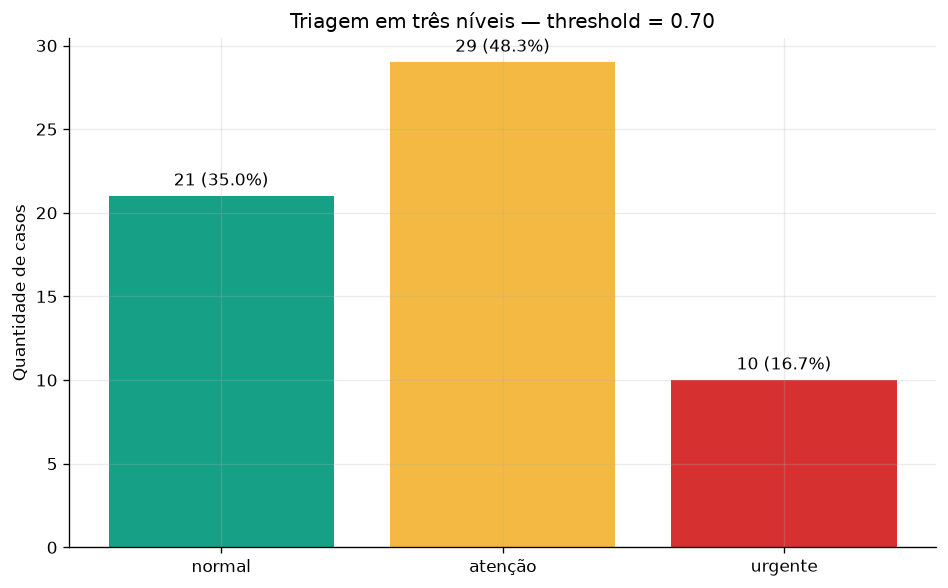

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    distribution["classe"],
    distribution["quantidade"],
    color=[COLORS[label] for label in distribution["classe"]],
)

ax.bar_label(
    bars,
    labels=[
        f"{count} ({pct:.1%})"
        for count, pct in zip(
            distribution["quantidade"],
            distribution["percentual"],
        )
    ],
    padding=4,
)

ax.set_title(
    f"Triagem em três níveis — threshold = {CONFIDENCE_THRESHOLD:.2f}"
)
ax.set_ylabel("Quantidade de casos")

plt.tight_layout()
plt.show()

## 5. Visualização da zona de decisão

O gráfico mostra o `urgent_score`:

- valores altos → urgente;
- valores baixos → normal;
- região central → atenção.

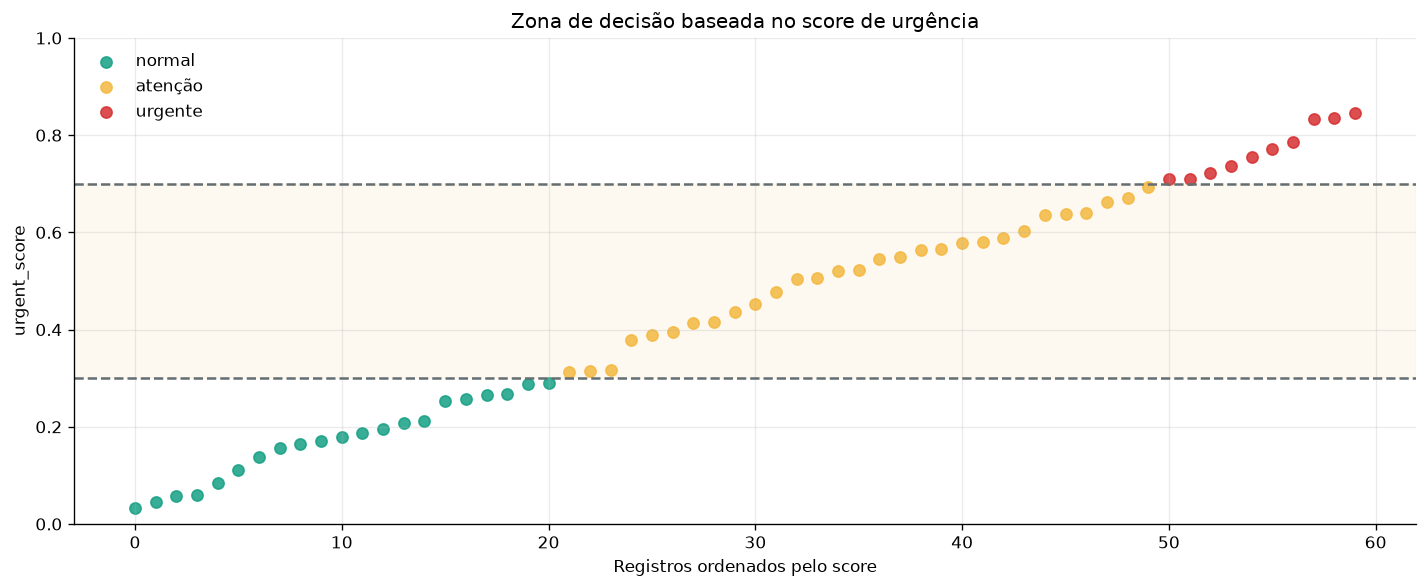

In [6]:
sorted_pilot = pilot.sort_values("urgent_score").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))

for triage_class in order:
    mask = sorted_pilot["triage_level"] == triage_class
    ax.scatter(
        sorted_pilot.index[mask],
        sorted_pilot.loc[mask, "urgent_score"],
        label=triage_class,
        color=COLORS[triage_class],
        s=45,
        alpha=0.85,
    )

lower_boundary = 1 - CONFIDENCE_THRESHOLD
upper_boundary = CONFIDENCE_THRESHOLD

ax.axhline(
    lower_boundary,
    color="#636E72",
    linestyle="--",
    linewidth=1.5,
)
ax.axhline(
    upper_boundary,
    color="#636E72",
    linestyle="--",
    linewidth=1.5,
)

ax.axhspan(
    lower_boundary,
    upper_boundary,
    color="#F4B942",
    alpha=0.08,
)

ax.set_title("Zona de decisão baseada no score de urgência")
ax.set_xlabel("Registros ordenados pelo score")
ax.set_ylabel("urgent_score")
ax.set_ylim(0, 1)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## 6. Sensibilidade ao threshold

Quanto maior o threshold, maior tende a ser a classe `atenção`.

In [7]:
thresholds = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85]

threshold_results = []

for threshold in thresholds:
    labels_for_threshold = pilot.apply(
        lambda row: map_to_three_levels(
            urgent_score=row["urgent_score"],
            nonurgent_score=row["nonurgent_score"],
            threshold=threshold,
        ),
        axis=1,
    )

    counts = labels_for_threshold.value_counts()

    threshold_results.append(
        {
            "threshold": threshold,
            "normal": counts.get("normal", 0),
            "atenção": counts.get("atenção", 0),
            "urgente": counts.get("urgente", 0),
        }
    )

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,threshold,normal,atenção,urgente
0,0.6000,27,16,17
1,0.6500,24,23,13
2,0.7000,21,29,10
3,0.7500,15,39,6
4,0.8000,13,44,3
5,0.8500,7,53,0


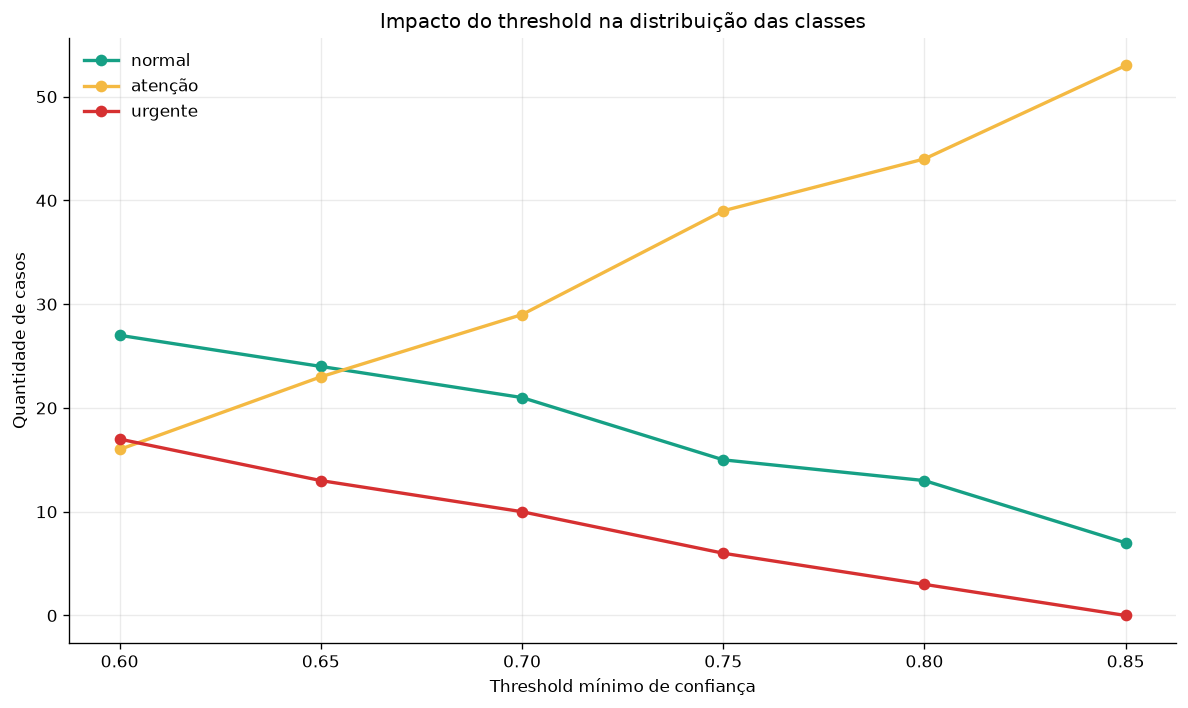

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

for triage_class in order:
    ax.plot(
        threshold_df["threshold"],
        threshold_df[triage_class],
        marker="o",
        linewidth=2,
        label=triage_class,
        color=COLORS[triage_class],
    )

ax.set_title("Impacto do threshold na distribuição das classes")
ax.set_xlabel("Threshold mínimo de confiança")
ax.set_ylabel("Quantidade de casos")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### Interpretação

- threshold baixo: mais decisões diretas como `normal` ou `urgente`;
- threshold alto: mais registros caem em `atenção`.

O valor `0.70` é usado apenas como ponto inicial de projeto. Ele deve ser documentado e pode ser ajustado após inspeção dos resultados.

## 7. Exemplos por classe

In [9]:
for triage_class in order:
    display(Markdown(f"### {triage_class.upper()}"))

    examples = (
        pilot.loc[pilot["triage_level"] == triage_class]
        .sort_values("confidence", ascending=False)
        [
            [
                "medical_abstract",
                "urgent_score",
                "nonurgent_score",
                "confidence",
            ]
        ]
        .head(5)
    )

    display(examples)

### NORMAL

,medical_abstract,urgent_score,nonurgent_score,confidence
46,Stressful events and life satisfaction among elderly men and women. The purpose of this study was to examine the int...,0.0331,0.9669,0.9669
48,The relationship of headache symptoms with severity and duration of attacks. Efforts to develop clinically useful he...,0.0461,0.9539,0.9539
13,Vitamin E and cancer prevention. Some animal experiments and human studies suggest that vitamin E may protect agains...,0.0569,0.9431,0.9431
34,Corporate-sponsored breast cancer screening at the work site: results of a statewide program. Mobile screening mammo...,0.0601,0.9399,0.9399
9,Serological evidence of infection with Helicobacter pylori may predict gastrointestinal intolerance to non-steroidal...,0.0840,0.9160,0.9160


### ATENÇÃO

,medical_abstract,urgent_score,nonurgent_score,confidence
54,Fludarabine: a new agent with marked cytoreductive activity in untreated chronic lymphocytic leukemia. Thirty-three ...,0.6935,0.3065,0.6935
33,Critical ischemia times and survival patterns of experimental pig flaps. Previous work on critical ischemia time sug...,0.3131,0.6869,0.6869
11,Simultaneous measurement of myocardial perfusion and ventricular function during exercise from a single injection of...,0.3139,0.6861,0.6861
17,Imaging techniques in the diagnosis of carcinoma of the colon. The variability in the published results for colonosc...,0.3167,0.6833,0.6833
19,"Mechanism of stroke in patients taking aspirin. During a 1-year period, we prospectively studied the mechanism and s...",0.6707,0.3293,0.6707


### URGENTE

,medical_abstract,urgent_score,nonurgent_score,confidence
6,Warning: fatal reaction to the use of fibrin glue in deep hepatic wounds. Case reports. Two cases of severe hypotens...,0.8448,0.1552,0.8448
10,"Vascular complications after orthotopic liver transplantation. Over a 57-month period, we performed 430 orthotopic l...",0.8362,0.1638,0.8362
22,"Postpartum hemorrhage: placenta accreta, uterine inversion, and puerperal hematomas. Puerperal hematomas, although r...",0.8340,0.1660,0.8340
39,Implications of echocardiographically assisted diagnosis of pericardial tamponade in contemporary medical patients: ...,0.7869,0.2131,0.7869
41,Brain and spinal cord hemorrhage in long-term survivors of malignant pediatric brain tumors: a possible late effect ...,0.7710,0.2290,0.7710


## 8. Casos classificados como atenção

Esses casos não foram classificados como `atenção` porque o BioBERT aprendeu essa classe.  
Eles estão nessa categoria porque ficaram dentro da **zona de incerteza definida pelo projeto**.

In [10]:
attention_cases = (
    pilot.loc[pilot["triage_level"] == "atenção"]
    .assign(distance_from_middle=lambda df: (df["urgent_score"] - 0.5).abs())
    .sort_values("distance_from_middle")
    [
        [
            "medical_abstract",
            "urgent_score",
            "nonurgent_score",
            "confidence",
        ]
    ]
)

display(attention_cases.head(15))

,medical_abstract,urgent_score,nonurgent_score,confidence
45,Global and molecular hemostatic markers in acute myeloid leukemia. Patients with acute myeloid leukemia have multipl...,0.5044,0.4956,0.5044
57,Ratio of immunochemically determined amniotic fluid acetylcholinesterase to butyrylcholinesterase in the differentia...,0.5071,0.4929,0.5071
51,Relative risks of left ventricular aneurysmectomy in patients with akinetic scars versus true dyskinetic aneurysms. ...,0.5196,0.4804,0.5196
59,Bleeding from duodenal lymphangiectasia. An 8 year old girl with recurrent upper gastrointestinal bleeding was found...,0.5223,0.4777,0.5223
3,Indirect revascularization of the lower extremity by means of microvascular free-muscle flap--a preliminary report. ...,0.4769,0.5231,0.5231
56,Antitumor activity of liposome-encapsulated doxorubicin in advanced breast cancer: phase II study. Previous studies ...,0.5460,0.4540,0.5460
23,Giant cell tumor of bone. A clinicopathologic and DNA flow cytometric analysis. Flow cytometric DNA analysis was per...,0.4529,0.5471,0.5471
18,Thromboembolism. A complication of weekly chemotherapy in the treatment of non-Hodgkin's lymphoma. In a retrospectiv...,0.5499,0.4501,0.5499
27,The pharmacology of intravenous and oral etoposide. The epipodophyllotoxin derivative etoposide (VP-16) has been in ...,0.5629,0.4371,0.5629
28,Minute squamous cell carcinoma arising in the wall of a congenital lung cyst. A case of minute squamous cell carcino...,0.4368,0.5632,0.5632


## 9. Exportação

In [11]:
output_file = PROCESSED_DIR / "triage_pilot_three_levels.csv"

pilot.to_csv(output_file, index=False)

print(f"Arquivo salvo em: {output_file}")

Arquivo salvo em: C:\Users\erick\projetos\medical-triage-mlops\data\processed\triage_pilot_three_levels.csv


## 10. Conclusão metodológica

A estratégia utilizada é uma **adaptação de um classificador binário com zona de incerteza**:

```text
urgent com alta confiança      → urgente
resultado incerto              → atenção
non-urgent com alta confiança  → normal
```

No trabalho, a classe `atenção` deve ser apresentada como:

> casos em que o modelo pré-treinado não demonstrou confiança suficiente para classificá-los como claramente urgentes ou não urgentes, sendo encaminhados para uma categoria intermediária de atenção.

Ela não deve ser descrita como uma classe clínica originalmente aprendida pelo BioBERT.